In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

#for better plot style
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r"D:\1. Prasad\Project\customer-churn-analysis\data\archive\churn.csv.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

Text(0.5, 1.0, 'Tenure Distribution by Churn Status')

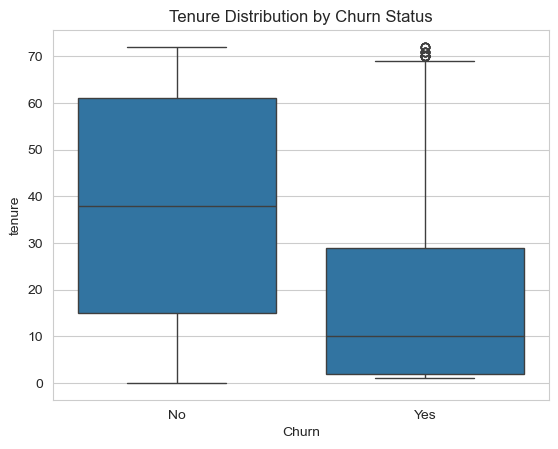

In [8]:
sns.boxplot(x = "Churn", y = "tenure", data = df)
plt.title("Tenure Distribution by Churn Status")
#Customers who churn have significantly lower tenure compared to retained customers.
#The median tenure of churned customers is much lower, indicating that early-stage customer retention is critical.

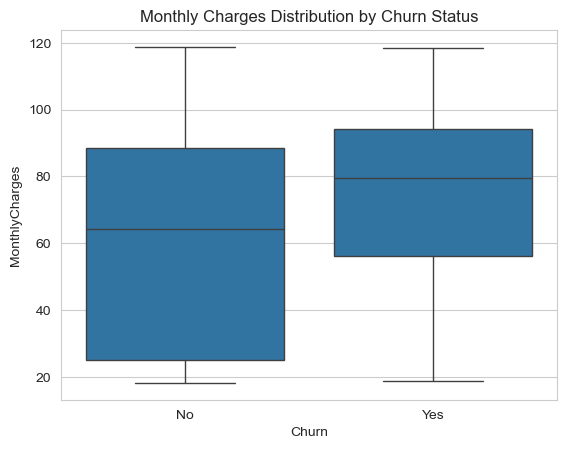

In [9]:
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = df)
plt.title("Monthly Charges Distribution by Churn Status")
plt.show()
# Customers who churn have noticeably higher monthly charges compared to retained customers.
# The median monthly charge for churned customers is significantly higher, indicating potential price 
# sensitivity or dissatisfaction with perceived value.

In [10]:
a = df.groupby('Contract').size()
b = df[df['Churn'] == 'Yes'].groupby('Contract').size()
c = ((b/a).fillna(0) * 100)

In [11]:
c

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
dtype: float64

In [12]:
c = c.reset_index()
c.columns = ['Contract', 'Churn_Percentage']

Text(0, 0.5, 'Churn %')

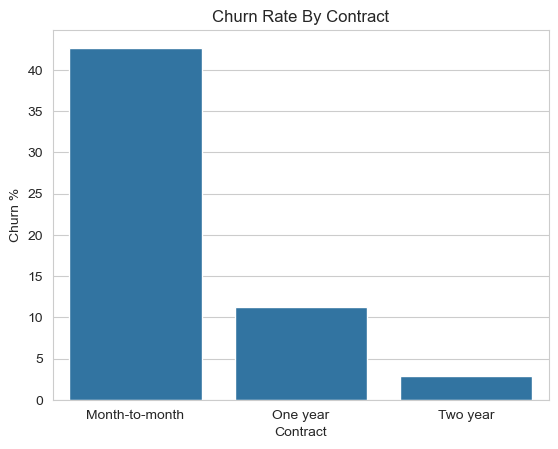

In [31]:
sns.barplot(x = 'Contract', y = 'Churn_Percentage', data = c)
plt.title('Churn Rate By Contract')
plt.ylabel('Churn %')

In [50]:
a1 = df.groupby('InternetService').size()
b1 = df[df['Churn'] == 'Yes'].groupby(['InternetService']).size()
c1 = (b1 / a1) * 100

In [52]:
c1 = c1.reset_index()
c1.columns = ['InternetService', 'Churn_Percentage']

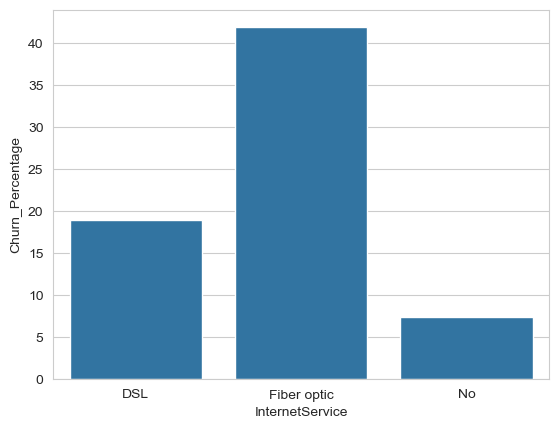

In [58]:
sns.barplot(x = 'InternetService', y = 'Churn_Percentage', data = c1);
# Fiber optic customers exhibit the highest churn rate (~42%), significantly higher than DSL (~19%) and 
# customers without internet (~7%). This suggests that premium internet users are disproportionately 
# contributing to customer attrition.

In [56]:
c1.head()

,InternetService,Churn_Percentage
0,DSL,18.959108
1,Fiber optic,41.892765
2,No,7.404980
